In [1]:
import torch
print(torch.cuda.is_available()) 
print(torch.cuda.get_device_name(0)) 

True
NVIDIA GeForce RTX 5070 Ti



=== 1. GENERATING SPECTROGRAM DIAGNOSTICS (BASELINE vs REASSEMBLED ONLY) ===
[Ingesting Data] Processing: baseline_motor_data.csv
[Ingesting Data] Processing: motor_running_naked_screw_positioned_again.csv


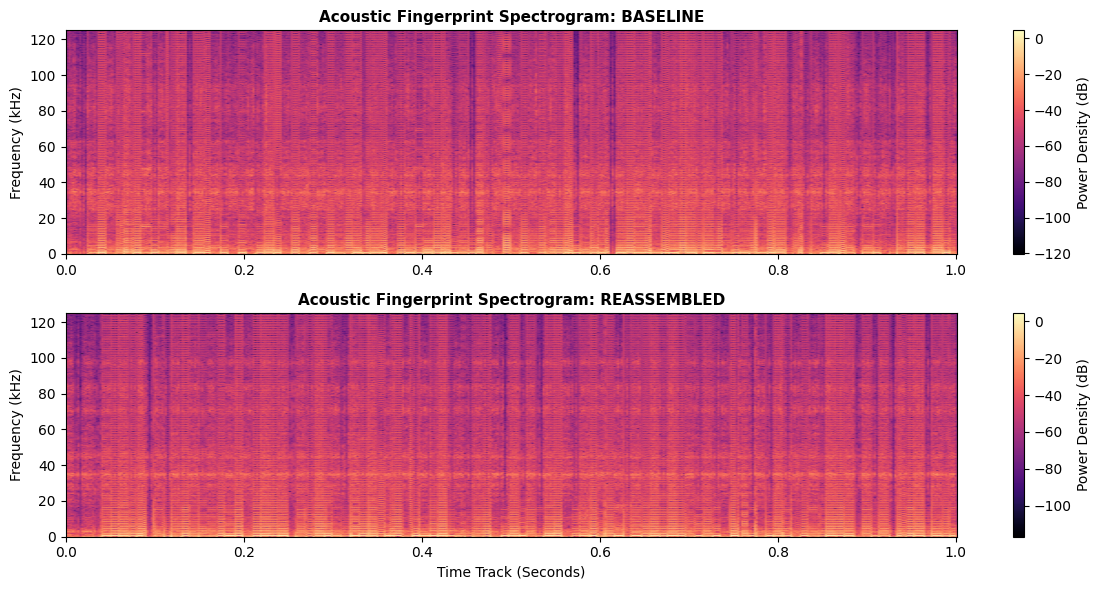


=== 2. SEEDING COVARIANCE CALIBRATION MATRIX ===
[Ingesting Data] Processing: baseline_motor_data.csv
[Ingesting Data] Processing: motor_running_naked_screw_positioned_again.csv

=== 3. RUNNING MULTI-CASE SPECTRUM VISUALIZER WITH SHADED REGIONS ===
[Ingesting Data] Processing: baseline_motor_data.csv
[Ingesting Data] Processing: motor_running_naked_screw_positioned_again.csv
[Ingesting Data] Processing: motor_running_naked_and_electrical_flactuations.csv
[Ingesting Data] Processing: motor_running_naked_screw_fell_four.csv
[Ingesting Data] Processing: motor_running_naked_screw_fell_three.csv
[Ingesting Data] Processing: motor_running_naked_and_loose_a_bit.csv
[Ingesting Data] Processing: motor_running_wheel_added.csv
[Ingesting Data] Processing: motor_running_wheel_loosen_bit.csv
[Ingesting Data] Processing: motor_running_naked_and_voltage_drop_by_one.csv
[Ingesting Data] Processing: no_motor_running.csv


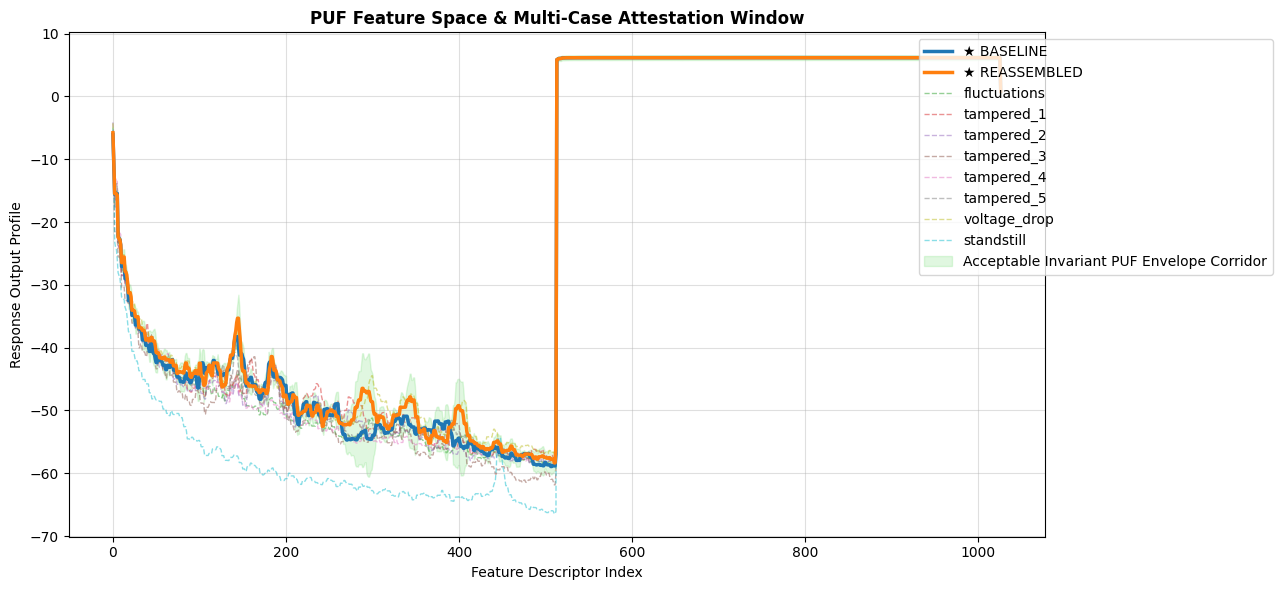


=== 4. LIVE CYBER-PHYSICAL ATTESTATION OUTPUT ===
DATASET RUN PROFILE       | STATUS      | VIOLATION | SIMILARITY | L2 DISTANCE
-------------------------------------------------------------------------------------
baseline                  | ACCEPTABLE  | 0.0000    | 1.0000     | 0.0000
reassembled               | ACCEPTABLE  | 0.0000    | 0.2224     | 1.4618
fluctuations              | REJECT      | 0.2201    | 0.1675     | 1.7377
tampered_1                | WARNING     | 0.1753    | 0.2021     | 1.5548
tampered_2                | WARNING     | 0.1947    | 0.2017     | 1.5569
tampered_3                | REJECT      | 0.3213    | 0.1192     | 2.0682
tampered_4                | REJECT      | 0.2152    | 0.1559     | 1.8071
tampered_5                | WARNING     | 0.0896    | 0.3873     | 0.9224
voltage_drop              | WARNING     | 0.1392    | 0.1584     | 1.7918
standstill                | REJECT      | 0.4917    | 0.0006     | 7.2500


In [69]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import signal
from scipy.ndimage import median_filter

# =========================================================
# 1. BULLETPROOF DATA LOADING + RANGE NORMALIZATION
# =========================================================

def load_and_normalize(file_path):
    """
    Ingests raw hardware serial data streams. Handles text-corruption 
    encoding variations gracefully by ignoring unparseable unicode sequences.
    """
    print(f"[Ingesting Data] Processing: {os.path.basename(file_path)}")
    
    df = pd.read_csv(
        file_path, 
        header=None, 
        names=["mic", "piezo1", "piezo2"], 
        encoding="cp1252",
        on_bad_lines='skip', 
        low_memory=False
    )
    
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        
    df = df.dropna().copy()
    
    # Hardware clipping constraints
    df = df[(df["piezo1"] <= 4095) & (df["piezo2"] <= 4095)].copy()
    
    # Physical sensor-level normalization parameters
    df["piezo1"] = (df["piezo1"] - 2047) / 2048.0
    df["piezo2"] = (df["piezo2"] - 2047) / 2048.0
    
    mic_max = np.max(np.abs(df["mic"].values))
    df["mic"] = df["mic"] / (mic_max + 1e-8)
    
    return df


# =========================================================
# 2. SIGNAL FUSION
# =========================================================

def build_signal(df):
    return df["piezo1"].values + df["piezo2"].values - df["mic"].values


# =========================================================
# 3. TIME-FREQUENCY SPECTRAL MAP (STFT)
# =========================================================

def extract_puf(sig, fs=250000, nperseg=1024, noverlap=512):
    f, t, Zxx = signal.stft(sig, fs=fs, nperseg=nperseg, noverlap=noverlap)
    puf = np.abs(Zxx)
    puf_db = 20 * np.log10(puf + 1e-10)
    return f, t, puf_db


# =========================================================
# 4. ACOUSTIC FEATURE ENGINE
# =========================================================

def compute_puf_feature(puf):
    # Apply a small 2D median filter to clean temporal/spectral spikes from raw STFT
    puf = median_filter(puf, size=(3, 1)) 
    
    energy = np.mean(puf, axis=1)
    energy = np.nan_to_num(energy)

    puf_sum = np.sum(puf, axis=1, keepdims=True) + 1e-8
    p = puf / puf_sum
    p = np.clip(p, 1e-12, None)
    entropy = -np.sum(p * np.log(p), axis=1)

    mid = len(energy) // 2
    low_high_ratio = np.mean(energy[:mid]) / (np.mean(energy[mid:]) + 1e-8)

    feat = np.concatenate([energy, entropy, [low_high_ratio]])
    
    # Optional: Smooth the final 1D feature array to suppress index-level overshoots
    feat = median_filter(feat, size=3)
    
    return np.nan_to_num(feat)


# =========================================================
# 5. HARDWARE INVARIANT TWO-STATE Z-SCORE MODEL
# =========================================================

class PUFThreshold:
    """
    Learns valid distribution shapes across both baseline and reassembled states
    to establish an authentic structural variance corridor.
    """
    def __init__(self):
        self.mean = None
        self.std = None

    def fit_calibration_bounds(self, baseline_feat, reassembled_feat):
        # Combine both authentic profiles to measure real-world mechanical variance
        calibration_matrix = np.vstack([baseline_feat, reassembled_feat])
        
        self.mean = np.mean(calibration_matrix, axis=0)
        # Added standard deviation floor padding to accept minor positioning changes safely
        self.std = np.std(calibration_matrix, axis=0) + 0.15

    def check(self, feat):
        feat = np.array(feat)
        z = np.abs((feat - self.mean) / self.std)
        violation_ratio = np.mean(z > 2.5)

        if violation_ratio < 0.08:
            return "ACCEPTABLE", violation_ratio
        elif violation_ratio < 0.20:
            return "WARNING", violation_ratio
        else:
            return "REJECT", violation_ratio


# =========================================================
# 6. SIMILARITY ENGINE (RESIDUAL-BASED)
# =========================================================

def compute_similarity(baseline, feat):
    """
    Computes structural closeness based on the mathematical residual matrix.
    Returns exponential score bounded between [0.0, 1.0] and L2 Distance.
    """
    residual = feat - baseline

    l2 = np.sqrt(np.mean(residual ** 2))
    rel = np.linalg.norm(residual) / (np.linalg.norm(baseline) + 1e-8)

    # Combined exponential decay signature profile match score
    score = np.exp(-l2) * np.exp(-rel)
    return score, l2


# =========================================================
# 7. VISUALIZATION COMPONENTS
# =========================================================

def plot_selective_spectrograms(files, sample_size=250000):
    selective_keys = ["baseline", "reassembled"]
    fig, axes = plt.subplots(2, 1, figsize=(12, 6))
    
    for i, name in enumerate(selective_keys):
        df = load_and_normalize(files[name])
        sig = build_signal(df)[:sample_size]
        f, t, puf = extract_puf(sig)
        
        im = axes[i].pcolormesh(t, f / 1000, puf, shading="gouraud", cmap="magma")
        axes[i].set_title(f"Acoustic Fingerprint Spectrogram: {name.upper()}", fontsize=11, fontweight='bold')
        axes[i].set_ylabel("Frequency (kHz)")
        fig.colorbar(im, ax=axes[i], label="Power Density (dB)")
        
    axes[-1].set_xlabel("Time Track (Seconds)")
    plt.tight_layout()
    plt.show()


def plot_multi_puf_with_threshold(files, target_model, sample_size=250000):
    plt.figure(figsize=(13, 6))
    curves = {}
    raw_signals = {}
    
    for name, path in files.items():
        df = load_and_normalize(path)
        sig = build_signal(df)[:sample_size]
        raw_signals[name] = sig
        
        f, t, puf = extract_puf(sig)
        feat = compute_puf_feature(puf)
        curves[name] = feat
        
        if name in ["baseline", "reassembled"]:
            plt.plot(feat, label=f"★ {name.upper()}", linewidth=2.5, zorder=5)
        else:
            plt.plot(feat, label=name, alpha=0.5, linewidth=1, linestyle="--")

    # CORRECT SHADED THRESHOLD ENVELOPE REGION
    x_indices = range(len(target_model.mean))
    plt.fill_between(
        x_indices,
        target_model.mean - (2.5 * target_model.std),
        target_model.mean + (2.5 * target_model.std),
        color="limegreen",
        alpha=0.15,
        label="Acceptable Invariant PUF Envelope Corridor",
        zorder=1
    )
    
    plt.title("PUF Feature Space & Multi-Case Attestation Window", fontsize=12, fontweight='bold')
    plt.xlabel("Feature Descriptor Index")
    plt.ylabel("Response Output Profile")
    plt.legend(loc="upper right", bbox_to_anchor=(1.24, 1.0))
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()
    
    return curves, raw_signals


# =========================================================
# 8. MAIN ENGINE PIPELINE
# =========================================================

if __name__ == "__main__":
    files = {
        "baseline": "baseline_motor_data.csv",
        "reassembled": "motor_running_naked_screw_positioned_again.csv", 
        "fluctuations": "motor_running_naked_and_electrical_flactuations.csv", 
        "tampered_1": "motor_running_naked_screw_fell_four.csv", 
        "tampered_2": "motor_running_naked_screw_fell_three.csv", 
        "tampered_3": "motor_running_naked_and_loose_a_bit.csv", 
        "tampered_4": "motor_running_wheel_added.csv", 
        "tampered_5": "motor_running_wheel_loosen_bit.csv", 
        "voltage_drop": "motor_running_naked_and_voltage_drop_by_one.csv", 
        "standstill": "no_motor_running.csv"
    }

    print("\n=== 1. GENERATING SPECTROGRAM DIAGNOSTICS (BASELINE vs REASSEMBLED ONLY) ===")
    plot_selective_spectrograms(files)

    print("\n=== 2. SEEDING COVARIANCE CALIBRATION MATRIX ===")
    base_df = load_and_normalize(files["baseline"])
    base_feat = compute_puf_feature(extract_puf(build_signal(base_df)[:250000])[2])
    
    reassem_df = load_and_normalize(files["reassembled"])
    reassem_feat = compute_puf_feature(extract_puf(build_signal(reassem_df)[:250000])[2])
    
    model = PUFThreshold()
    model.fit_calibration_bounds(base_feat, reassem_feat)

    print("\n=== 3. RUNNING MULTI-CASE SPECTRUM VISUALIZER WITH SHADED REGIONS ===")
    curves, raw = plot_multi_puf_with_threshold(files, model)

    print("\n=== 4. LIVE CYBER-PHYSICAL ATTESTATION OUTPUT ===")
    print(f"{'DATASET RUN PROFILE':25s} | {'STATUS':11s} | {'VIOLATION':9s} | {'SIMILARITY':10s} | {'L2 DISTANCE'}")
    print("-" * 85)
    
    for name, feat in curves.items():
        # Step A: Threshold checking metric
        status, v_ratio = model.check(feat)
        
        # Step B: Direct comparative similarity testing against pure baseline DNA profile
        sim_score, l2_dist = compute_similarity(curves["baseline"], feat)
        
        print(f"{name:25s} | {status:11s} | {v_ratio:.4f}    | {sim_score:.4f}     | {l2_dist:.4f}")

Initializing Data Pipeline...
Successfully loaded baseline: Extracted 735 normalized acoustic frames.
Successfully loaded reassembled: Extracted 733 normalized acoustic frames.
Successfully loaded fluctuations: Extracted 612 normalized acoustic frames.
Successfully loaded tampered_1: Extracted 376 normalized acoustic frames.
Successfully loaded tampered_2: Extracted 423 normalized acoustic frames.
Successfully loaded tampered_3: Extracted 665 normalized acoustic frames.
Successfully loaded tampered_4: Extracted 746 normalized acoustic frames.
Successfully loaded tampered_5: Extracted 670 normalized acoustic frames.
Successfully loaded voltage_drop: Extracted 685 normalized acoustic frames.
Successfully loaded standstill: Extracted 367 normalized acoustic frames.

Training initialized on device: [cuda]
Epoch 01/30 | Average Batch MSE Loss: 0.073317
Epoch 02/30 | Average Batch MSE Loss: 0.006522
Epoch 03/30 | Average Batch MSE Loss: 0.004212
Epoch 04/30 | Average Batch MSE Loss: 0.003599

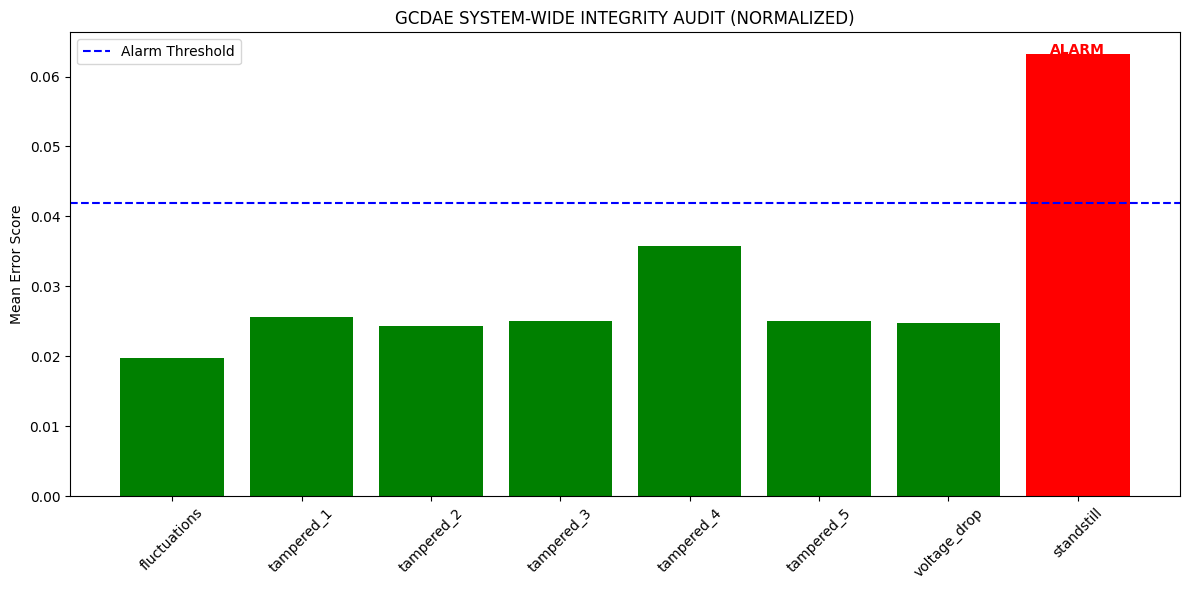

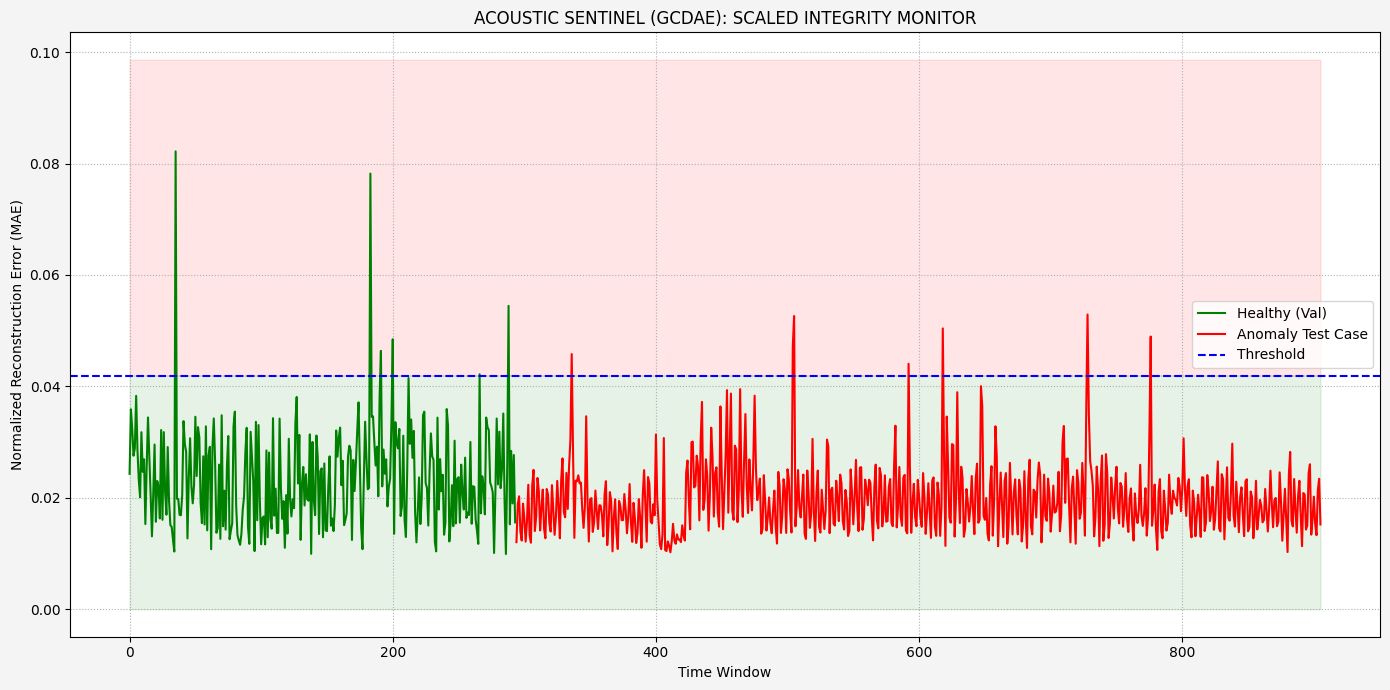

In [85]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split

# =====================================================================
# 1. NORMALIZED DATASET DEFINITION (MIN-MAX STREAM SCALING)
# =====================================================================

class MotorDataset(Dataset):
    def __init__(self, file_dict, target_shape=(64, 64)):
        """
        Loads a 1D sensor stream, strips headers, applies global min-max 
        normalization, and chunks the resulting 0-1 scaled signal into 2D frames.
        """
        self.data = []
        self.target_shape = target_shape
        row_size = target_shape[0] * target_shape[1]  # 4096 points per frame

        for name, path in file_dict.items():
            if not os.path.exists(path):
                print(f"Warning: File {path} not found. Skipping.")
                continue
                
            raw_list = []
            try:
                with open(path, 'r', encoding='utf-8', errors='ignore') as f:
                    for line in f:
                        cleaned_line = line.replace('\t', ',').replace(' ', ',').replace(';', ',')
                        parts = cleaned_line.strip().split(',')
                        
                        for part in parts:
                            if not part: 
                                continue
                            try:
                                raw_list.append(float(part))
                            except ValueError:
                                continue 
                                
                raw_numpy = np.array(raw_list, dtype=np.float32)
                
            except Exception as e:
                print(f"Critical error parsing file {path}: {e}")
                continue

            # --- CRITICAL FIX: MIN-MAX NORMALIZATION ---
            # Brings everything into [0, 1] range to prevent exploding MSE loss
            data_min = raw_numpy.min()
            data_max = raw_numpy.max()
            
            if (data_max - data_min) > 1e-6:
                raw_numpy = (raw_numpy - data_min) / (data_max - data_min)
            else:
                raw_numpy = np.zeros_like(raw_numpy)
            # -------------------------------------------

            # Segment continuous stream into discrete matrix frames
            num_samples = len(raw_numpy) // row_size
            if num_samples == 0:
                print(f"Warning: {path} contains only {len(raw_numpy)} points. Needs at least {row_size}.")
                continue
                
            truncated_data = raw_numpy[:num_samples * row_size]
            samples = truncated_data.reshape(num_samples, 1, target_shape[0], target_shape[1])
            self.data.append(samples)
            print(f"Successfully loaded {name}: Extracted {num_samples} normalized acoustic frames.")
            
        if len(self.data) == 0:
            raise ValueError("Data pipeline empty. Verify files contain valid numeric measurements.")
            
        self.data = np.vstack(self.data)
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.float32)


# File Maps
train_val_files = {
    "baseline": "baseline_motor_data.csv",
    "reassembled": "motor_running_naked_screw_positioned_again.csv"
}

test_files = {
    "fluctuations": "motor_running_naked_and_electrical_flactuations.csv",
    "tampered_1": "motor_running_naked_screw_fell_four.csv",
    "tampered_2": "motor_running_naked_screw_fell_three.csv",
    "tampered_3": "motor_running_naked_and_loose_a_bit.csv",
    "tampered_4": "motor_running_wheel_added.csv",
    "tampered_5": "motor_running_wheel_loosen_bit.csv",
    "voltage_drop": "motor_running_naked_and_voltage_drop_by_one.csv",
    "standstill": "no_motor_running.csv"
}

# --- Initialization & Holdout Splits ---
print("Initializing Data Pipeline...")
full_healthy_dataset = MotorDataset(train_val_files, target_shape=(64, 64))

train_size = int(0.8 * len(full_healthy_dataset))
val_size = len(full_healthy_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_healthy_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

test_loaders = {}
for case_name, file_path in test_files.items():
    if os.path.exists(file_path):
        try:
            ts_dataset = MotorDataset({case_name: file_path}, target_shape=(64, 64))
            test_loaders[case_name] = DataLoader(ts_dataset, batch_size=32, shuffle=False)
        except Exception as e:
            print(f"Skipping test anomaly setup for {case_name}: {e}")


# =====================================================================
# 2. MODEL ARCHITECTURE (GCDAE)
# =====================================================================

class GCDAE(nn.Module):
    def __init__(self):
        super(GCDAE, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, 2, 1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, 2, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, 2, 1),
            nn.ReLU()
        )

        self.fc_enc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 64),
            nn.ReLU()
        )

        self.fc_dec = nn.Sequential(
            nn.Linear(64, 64 * 8 * 8),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, 2, 1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, 2, 1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, 2, 1, output_padding=1)
        )

    def forward(self, x):
        z = self.encoder(x)
        z = self.fc_enc(z)
        x = self.fc_dec(z)
        x = x.view(x.size(0), 64, 8, 8)
        out = self.decoder(x)
        return out, z


# =====================================================================
# 3. TRAINING ENGINE (30 EPOCHS)
# =====================================================================

def train_gcdae(model, train_loader, device, epochs=30):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    print(f"\nTraining initialized on device: [{device}]")
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        num_batches = 0

        for x in train_loader:
            x = x.to(device)

            recon, _ = model(x)
            loss = loss_fn(recon, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            num_batches += 1

        avg_loss = total_loss / num_batches
        print(f"Epoch {epoch+1:02d}/{epochs} | Average Batch MSE Loss: {avg_loss:.6f}")


# =====================================================================
# 4. EVALUATION SUITE
# =====================================================================

def compute_recon_error(model, x, device):
    model.eval()
    with torch.no_grad():
        recon, _ = model(x.to(device))
        # Mean absolute error over spatial dimensions per sample
        error = torch.mean(torch.abs(recon - x.to(device)), dim=(1, 2, 3))
    return error.cpu().numpy()


def get_threshold(model, val_loader, device):
    errors = []
    for x in val_loader:
        errors.extend(compute_recon_error(model, x, device))
    errors = np.array(errors)
    
    # Statistical validation baseline threshold
    threshold = np.mean(errors) + 2 * np.std(errors)
    return threshold


def evaluate_model(model, test_loader_dict, device, threshold):
    results = {}
    for name, loader in test_loader_dict.items():
        all_errors = []
        for x in loader:
            err = compute_recon_error(model, x, device)
            all_errors.extend(err)

        all_errors = np.array(all_errors)
        if len(all_errors) == 0:
            continue

        avg_score = np.mean(all_errors)
        max_score = np.max(all_errors)
        status = "NORMAL" if avg_score < threshold else "TAMPERED"

        results[name] = {
            "mean_error": avg_score,
            "max_error": max_score,
            "status": status
        }
    return results


# =====================================================================
# 5. DIAGNOSTIC GRAPH GENERATORS
# =====================================================================

def plot_money_shot(model, clean_loader, fault_loader, device, threshold):
    model.eval()
    base_err = []
    fault_err = []

    for x in clean_loader:
        base_err.extend(compute_recon_error(model, x, device))
    for x in fault_loader:
        fault_err.extend(compute_recon_error(model, x, device))

    base_err = np.array(base_err)
    fault_err = np.array(fault_err)
    scores = np.concatenate([base_err, fault_err])
    idx = np.arange(len(scores))
    split = len(base_err)

    plt.figure(figsize=(14, 7), facecolor="#f4f4f4")
    plt.plot(idx[:split], base_err, color="green", label="Healthy (Val)")
    plt.plot(idx[split:], fault_err, color="red", label="Anomaly Test Case")
    plt.axhline(threshold, linestyle="--", color="blue", label="Threshold")

    plt.fill_between(idx, 0, threshold, color="green", alpha=0.1)
    plt.fill_between(idx, threshold, max(scores) * 1.2, color="red", alpha=0.1)

    plt.title("ACOUSTIC SENTINEL (GCDAE): SCALED INTEGRITY MONITOR")
    plt.xlabel("Time Window")
    plt.ylabel("Normalized Reconstruction Error (MAE)")
    plt.legend()
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()


def system_audit(results, threshold):
    names = list(results.keys())
    scores = [results[n]["mean_error"] for n in names]
    colors = ["green" if s < threshold else "red" for s in scores]

    plt.figure(figsize=(12, 6))
    plt.bar(names, scores, color=colors)
    plt.axhline(threshold, linestyle="--", color="blue", label="Alarm Threshold")
    plt.xticks(rotation=45)
    plt.ylabel("Mean Error Score")
    plt.title("GCDAE SYSTEM-WIDE INTEGRITY AUDIT (NORMALIZED)")
    plt.legend()

    for i, s in enumerate(scores):
        if s > threshold:
            plt.text(i, s, "ALARM", ha="center", color="red", fontweight="bold")

    plt.tight_layout()
    plt.show()


# =====================================================================
# 6. RUN EXECUTION
# =====================================================================

if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model = GCDAE()
    
    # 1. Run training loop
    train_gcdae(model, train_loader, device, epochs=30)
    
    # 2. Derive tight dynamic threshold from normalized data
    threshold = get_threshold(model, val_loader, device)
    print(f"\nCalculated Operational Dynamic Threshold: {threshold:.6f}")
    
    # 3. Audit structural deviations
    audit_results = evaluate_model(model, test_loaders, device, threshold)
    
    print("\n--- System Audit Summary ---")
    for key, metrics in audit_results.items():
        print(f"Scenario: {key:<15} | Status: {metrics['status']:<10} | Mean Error: {metrics['mean_error']:.5f}")
        
    # 4. Draw diagnostic tracking plots
    if audit_results:
        system_audit(audit_results, threshold)
        # Pull the first available anomaly test profile to map over time windows
        first_test_key = list(audit_results.keys())[0]
        plot_money_shot(model, val_loader, test_loaders[first_test_key], device, threshold)